In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# =====================================================
# PATHS
# =====================================================

BASE_DIR = Path.cwd()
while not (BASE_DIR / "data").exists():
    BASE_DIR = BASE_DIR.parent

STEP1 = BASE_DIR / "outputs" / "step1"
STEP2 = BASE_DIR / "outputs" / "step2"

df_baseline = pd.read_excel(STEP1 / "rsv_lombardia.xlsx")
df_future = pd.read_csv(STEP2 / "future_scenarios.csv")

In [ ]:
# -----------------------------------------------------
# NOISE DEFINITION
# -----------------------------------------------------

INTENSITY_SD = 0.10   
TIMING_SD = 1.5 
NOISE_SD = 0.03

historical = df_baseline.copy()

# -----------------------------------------------------
# BUILD HISTORICAL CURVE
# -----------------------------------------------------

mean_curve = (
    historical
    .groupby("week")["rsv_inc_65_baseline_per_1000"]
    .mean()
    .reset_index()
)

full_weeks = pd.DataFrame({"week": range(1, 53)})
mean_curve = full_weeks.merge(mean_curve, on="week", how="left")

mean_curve["rsv_inc_65_baseline_per_1000"] = (
    mean_curve["rsv_inc_65_baseline_per_1000"]
    .interpolate(limit_direction="both")
)

future_seasons = df_future["flu_season"].unique()
simulated_curves = []

for f_season in future_seasons:

    base_curve = mean_curve.copy()

    # -------------------------------------------------
    # CONTROLLED STHOCASTIC INTENSITY
    # -------------------------------------------------

    intensity = np.random.normal(1.0, INTENSITY_SD)

    base_curve["inc_future"] = (
        base_curve["rsv_inc_65_baseline_per_1000"]
        * intensity
    )

    # -------------------------------------------------
    # TIMING SHIFT
    # -------------------------------------------------

    shift = int(np.round(np.random.normal(0, TIMING_SD)))
    base_curve["week"] = ((base_curve["week"] + shift - 1) % 52) + 1

    # -------------------------------------------------
    # NOISE APPLICATION
    # -------------------------------------------------

    noise = np.random.normal(1.0, NOISE_SD, len(base_curve))
    base_curve["inc_future"] *= noise
    base_curve["inc_future"] = base_curve["inc_future"].clip(lower=0)

    base_curve["flu_season"] = f_season

    simulated_curves.append(
        base_curve[["flu_season", "week", "inc_future"]]
    )

# -------------------------------------------------
# FUTURE OUTPUT
# -------------------------------------------------

df_inc_future = pd.concat(simulated_curves, ignore_index=True)

df_inc_future = df_inc_future.merge(
    df_future[["flu_season", "week"]],
    on=["flu_season", "week"],
    how="inner"
)

df_inc_future = (
    df_inc_future
    .drop_duplicates(subset=["flu_season","week"])
)

In [ ]:
# -----------------------------------------------------
# MERGE RESULTS 
# -----------------------------------------------------

df = df_future.merge(
    df_inc_future,
    on=["flu_season", "week"],
    how="left"
)

assert df["inc_future"].notna().all(), "Incidence merge failed"

df["epi_time"] = df["calendar_year"] + (df["week"] - 1) / 52

# -----------------------------------------------------
# EPIDEMIOLOGICAL BASELINE
# -----------------------------------------------------

POP_65 = 2_389_041
TARGET_HOSP_RATE = 0.10

df["cases_future"] = df["inc_future"] * POP_65 / 1000
df["hosp_baseline"] = df["cases_future"] * TARGET_HOSP_RATE

# -----------------------------------------------------
# SCENARIO SPECIFIC VACCINATION EFFECTS
# -----------------------------------------------------

VE_map = {
    "low": 0.50,
    "mid": 0.70,
    "high": 0.85
}

df["VE_used"] = df["scenario"].map(VE_map)

df["hosp_with_vaccine"] = (
    df["hosp_baseline"]
    * (1 - df["VE_used"] * df["vax_cov_lag2"])
).clip(lower=0)

df["hosp_avoided"] = (
    df["hosp_baseline"]
    - df["hosp_with_vaccine"]
).clip(lower=0)

# -----------------------------------------------------
# DEATHS
# -----------------------------------------------------

CFR = 0.0713

df["deaths_baseline"] = df["hosp_baseline"] * CFR
df["deaths_with_vaccine"] = df["hosp_with_vaccine"] * CFR

df["deaths_avoided"] = (
    df["deaths_baseline"]
    - df["deaths_with_vaccine"]
).clip(lower=0)

# -----------------------------------------------------
# 5. ECONOMIC MODEL
# -----------------------------------------------------

COST_PER_HOSP = 11_599
COST_PER_DOSE = 150

df["costs_saved"] = df["hosp_avoided"] * COST_PER_HOSP
df["vaccinated_weekly"] = df["vax_weekly"] * POP_65
df["vaccination_costs"] = df["vaccinated_weekly"] * COST_PER_DOSE
df["net_cost"] = df["vaccination_costs"] - df["costs_saved"]

# -----------------------------------------------------
# SUMMARY
# -----------------------------------------------------

summary = (
    df.groupby(["scenario", "flu_season"], as_index=False)[[
        "hosp_baseline",
        "hosp_with_vaccine",
        "hosp_avoided",
        "deaths_avoided",
        "vaccination_costs",
        "costs_saved",
        "net_cost"
    ]]
    .sum()
)

summary["cost_per_hosp_avoided"] = (
    summary["net_cost"] / summary["hosp_avoided"]
)

summary["cost_per_death_avoided"] = (
    summary["net_cost"] / summary["deaths_avoided"]
)

# -----------------------------------------------------
# OUTPUT
# -----------------------------------------------------

OUT = BASE_DIR / "outputs" / "step3"
OUT.mkdir(parents=True, exist_ok=True)

df.to_csv(OUT / "impact_timeseries_final.csv", index=False)
summary.to_csv(OUT / "impact_summary_final.csv", index=False)

print("Step 4 completed successfully with vaccination costs.")

Step 4 completed successfully with vaccination costs.


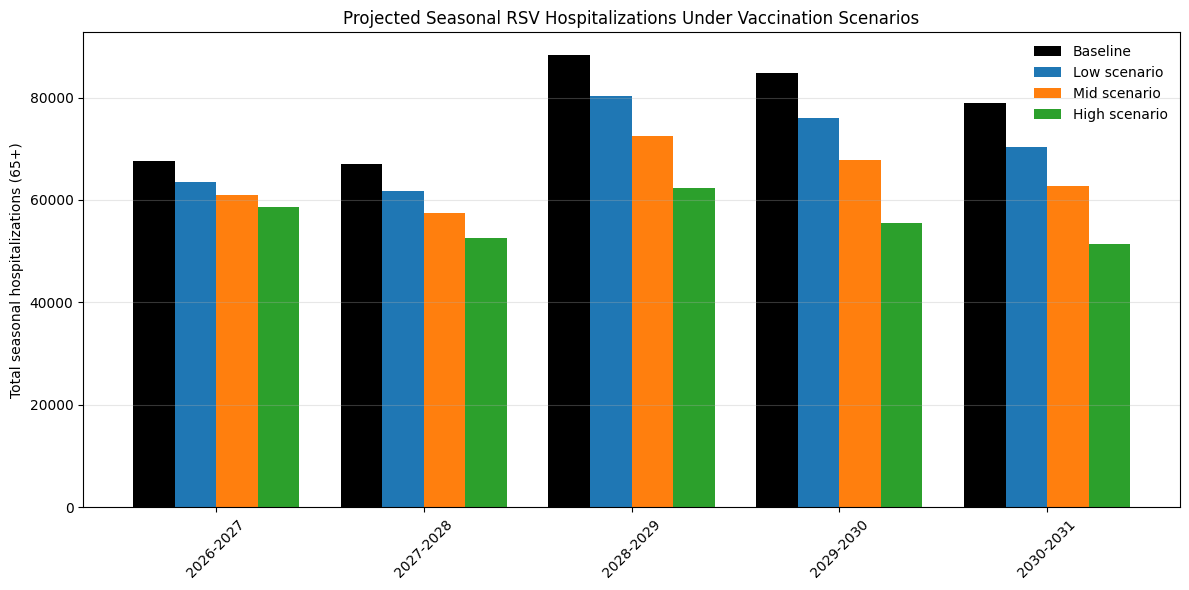

In [ ]:
# -----------------------------------------------------
# PLOT
# -----------------------------------------------------

season_totals = (
    df.groupby(["flu_season", "scenario"], as_index=False)[
        ["hosp_with_vaccine"]
    ]
    .sum()
)

baseline_totals = (
    df[df["scenario"] == "mid"]
    .groupby("flu_season", as_index=False)[
        ["hosp_baseline"]
    ]
    .sum()
)

season_pivot = season_totals.pivot(
    index="flu_season",
    columns="scenario",
    values="hosp_with_vaccine"
).reset_index()

season_pivot = season_pivot.merge(
    baseline_totals,
    on="flu_season",
    how="left"
)

season_pivot = season_pivot.sort_values("flu_season")

x = np.arange(len(season_pivot))
width = 0.2

plt.figure(figsize=(12,6))

plt.bar(x - 1.5*width, season_pivot["hosp_baseline"], width,
        label="Baseline", color="black")

plt.bar(x - 0.5*width, season_pivot["low"], width,
        label="Low scenario")

plt.bar(x + 0.5*width, season_pivot["mid"], width,
        label="Mid scenario")

plt.bar(x + 1.5*width, season_pivot["high"], width,
        label="High scenario")

plt.xticks(x, season_pivot["flu_season"], rotation=45)
plt.ylabel("Total seasonal hospitalizations (65+)")
plt.title("Projected Seasonal RSV Hospitalizations Under Vaccination Scenarios")

plt.legend(frameon=False)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / "seasonal_total_hospitalizations.png", dpi=300)
plt.show()

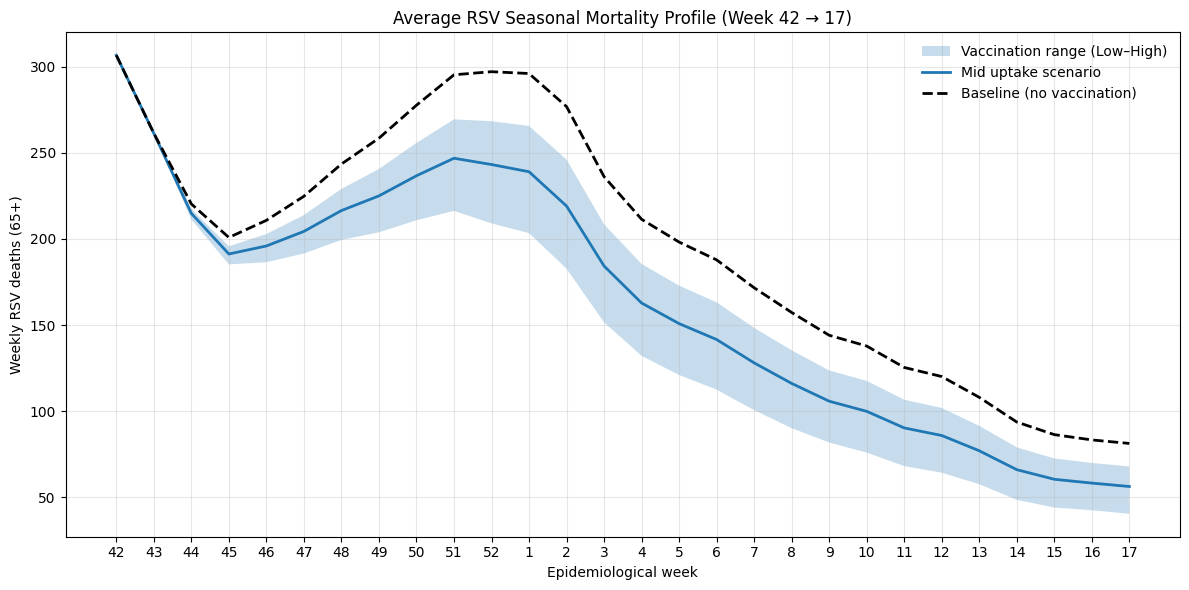

In [ ]:
df_season = df[
    (df["week"] >= 42) | (df["week"] <= 17)
].copy()


def seasonal_week(w):
    return w - 41 if w >= 42 else w + 11

df_season["seasonal_week"] = df_season["week"].apply(seasonal_week)


weekly_mean = (
    df_season.groupby(["seasonal_week", "scenario"], as_index=False)[
        ["deaths_with_vaccine"]
    ]
    .mean()
)

weekly_pivot = weekly_mean.pivot(
    index="seasonal_week",
    columns="scenario",
    values="deaths_with_vaccine"
).reset_index()

baseline_mean = (
    df_season[df_season["scenario"] == "mid"]
    .groupby("seasonal_week", as_index=False)[["deaths_baseline"]]
    .mean()
)

weekly_pivot = weekly_pivot.merge(
    baseline_mean,
    on="seasonal_week",
    how="left"
)

weekly_pivot = weekly_pivot.sort_values("seasonal_week")

week_labels = list(range(42,53)) + list(range(1,18))

plt.figure(figsize=(12,6))

plt.fill_between(
    weekly_pivot["seasonal_week"],
    weekly_pivot["low"],
    weekly_pivot["high"],
    alpha=0.25,
    label="Vaccination range (Low–High)"
)

plt.plot(
    weekly_pivot["seasonal_week"],
    weekly_pivot["mid"],
    linewidth=2,
    label="Mid uptake scenario"
)

plt.plot(
    weekly_pivot["seasonal_week"],
    weekly_pivot["deaths_baseline"],
    linestyle="--",
    linewidth=2,
    color="black",
    label="Baseline (no vaccination)"
)

plt.xticks(
    np.arange(1, len(week_labels)+1),
    week_labels,
    rotation=0
)

plt.xlabel("Epidemiological week")
plt.ylabel("Weekly RSV deaths (65+)")
plt.title("Average RSV Seasonal Mortality Profile (Week 42 → 17)")

plt.legend(frameon=False)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

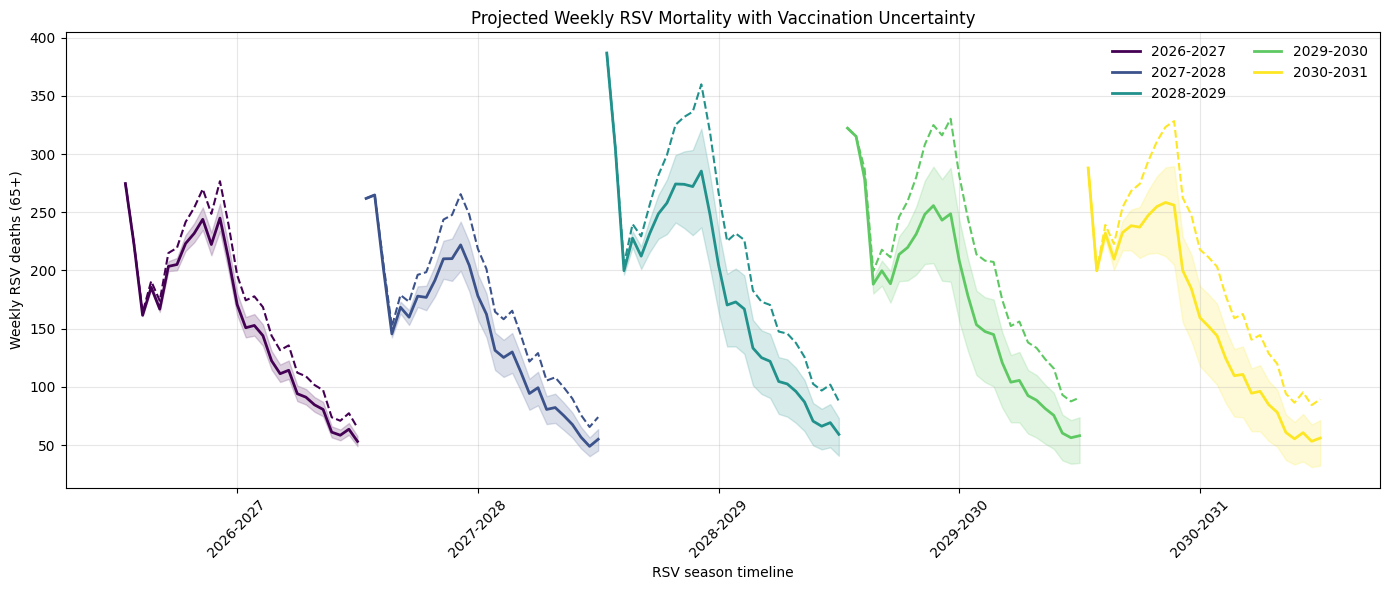

In [ ]:
df_plot = df[
    (df["week"] >= 42) | (df["week"] <= 17)
].copy()

def seasonal_pos(w):
    return w - 41 if w >= 42 else w + 11

df_plot["season_pos"] = df_plot["week"].apply(seasonal_pos)
seasons = sorted(df_plot["flu_season"].unique())
season_map = {s:i for i,s in enumerate(seasons)}

df_plot["season_id"] = df_plot["flu_season"].map(season_map)

SEASON_LENGTH = df_plot["season_pos"].max()

df_plot["global_week"] = (
    df_plot["season_id"] * SEASON_LENGTH
    + df_plot["season_pos"]
)

plt.figure(figsize=(14,6))

colors = plt.cm.viridis(np.linspace(0,1,len(seasons)))

for i, season in enumerate(seasons):

    d = df_plot[df_plot["flu_season"] == season]

    pivot = d.pivot_table(
        index="global_week",
        columns="scenario",
        values="deaths_with_vaccine",
        aggfunc="sum"
    ).reset_index()

    baseline = (
        d[d["scenario"]=="mid"]
        .groupby("global_week")["deaths_baseline"]
        .sum()
        .reset_index()
    )

    pivot = pivot.merge(baseline, on="global_week", how="left")
    pivot = pivot.sort_values("global_week")

    plt.fill_between(
        pivot["global_week"],
        pivot["low"],
        pivot["high"],
        color=colors[i],
        alpha=0.18
    )

    plt.plot(
        pivot["global_week"],
        pivot["mid"],
        color=colors[i],
        linewidth=2,
        label=f"{season}"
    )

    plt.plot(
        pivot["global_week"],
        pivot["deaths_baseline"],
        linestyle="--",
        color=colors[i],
        linewidth=1.5
    )

tick_positions = [
    i*SEASON_LENGTH + SEASON_LENGTH/2
    for i in range(len(seasons))
]

plt.xticks(tick_positions, seasons, rotation=45)

plt.xlabel("RSV season timeline")
plt.ylabel("Weekly RSV deaths (65+)")
plt.title("Projected Weekly RSV Mortality with Vaccination Uncertainty")

plt.legend(frameon=False, ncol=2)
plt.grid(alpha=0.3)
plt.savefig(OUT / "weekly_mortality.png", dpi=300)
plt.tight_layout()
plt.show()

In [ ]:
impact_5y = (
    df.groupby("scenario")[[
        "hosp_avoided",
        "deaths_avoided",
        "costs_saved",
        "vaccination_costs",
        "net_cost"
    ]]
    .sum()
    .reset_index()
)

impact_5y["ROI"] = (
    impact_5y["costs_saved"] /
    impact_5y["vaccination_costs"]
)

impact_5y["cost_per_hosp_avoided"] = (
    impact_5y["net_cost"] /
    impact_5y["hosp_avoided"]
)

impact_5y["cost_per_death_avoided"] = (
    impact_5y["net_cost"] /
    impact_5y["deaths_avoided"]
)

print(impact_5y)

impact_5y.to_csv(OUT / "impact_5year_summary.csv", index=False)

  scenario   hosp_avoided  deaths_avoided   costs_saved  vaccination_costs  \
0     high  106122.938142     7566.565489  1.230920e+09       1.040051e+09   
1      low   34715.890367     2475.242983  4.026696e+08       5.844901e+08   
2      mid   65089.396030     4640.873937  7.549719e+08       7.793218e+08   

       net_cost       ROI  cost_per_hosp_avoided  cost_per_death_avoided  
0 -1.908685e+08  1.183518           -1798.560332           -25225.250100  
1  1.818205e+08  0.688925            5237.384705            73455.605956  
2  2.434990e+07  0.968755             374.099363             5246.835388  
